## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [327]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Library to split data
from sklearn.model_selection import train_test_split

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to define a common seed value to be used throughout
RS=0

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [328]:
# loading the dataset
customer_data = pd.read_csv("Loan_Modelling.csv")

In [329]:
# copying the data to another variable to avoid any changes to original data
df = customer_data.copy()

## Data Overview

### Displaying the first few rows of the data

In [330]:
# viewing the first 5 rows of the data
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### Checking the shape of the dataset

In [331]:
df.shape

(5000, 14)

The dataset has 5000 rows and 14 columns

### Checking the data types of the columns for the dataset.

In [332]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


All the columns in the data are numeric. There are no null values for any column.

### Checking for missing values

In [333]:
# checking for missing values
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


* There are no missing values in the data.

### Checking for duplicate values

In [334]:
# checking the number of unique values in each column
df.nunique()

,0
ID,5000
Age,45
Experience,47
Income,162
ZIPCode,467
Family,4
CCAvg,108
Education,3
Mortgage,347
Personal_Loan,2


* There are no duplicate rows. This is 5000 unique customer's data.

In [335]:
df.drop(columns=["ID"], inplace=True)

We will drop the ID as it does not add any value to the analysis.

### Checking the Statistical Summary

In [336]:
# Let's look at the statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


Observations

* **Age and Experience**: The age and experience columns have similar ranges and standard deviations, suggesting they might be related. There are some negative values in the 'Experience' column, which is unusual and might require further investigation.
* **Income**: Income varies significantly, with a large standard deviation and a maximum value of 224, indicating a wide range of customer incomes.
* **ZIP Code**: ZIP Code is a numerical identifier, and the statistical summary doesn't provide much meaningful insight into its distribution.
* **Family Size**: The majority of customers have a family size between 1 and 4.
* **CCAvg (Credit Card Average Spending)**: The average spending on credit cards is relatively low, with a maximum of 10.
* **Education**: The education levels are represented as 1, 2, and 3, with a mean close to 2 (Graduate level).
* **Mortgage**: Many customers have no mortgage, as indicated by the 25th and 50th percentiles being 0. The maximum mortgage value is quite high at 635.
* **Personal Loan**: Only a small percentage of customers (around 9.6%) accepted the personal loan offer. This indicates an imbalanced dataset for the target variable.
* **Securities Account, CD Account, Online, and Credit Card**: These are binary variables (0 or 1) representing whether the customer has these accounts or services. The mean values indicate the proportion of customers who have them.


## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

The below functions need to be defined to carry out the EDA.

In [337]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [338]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Univariate analysis

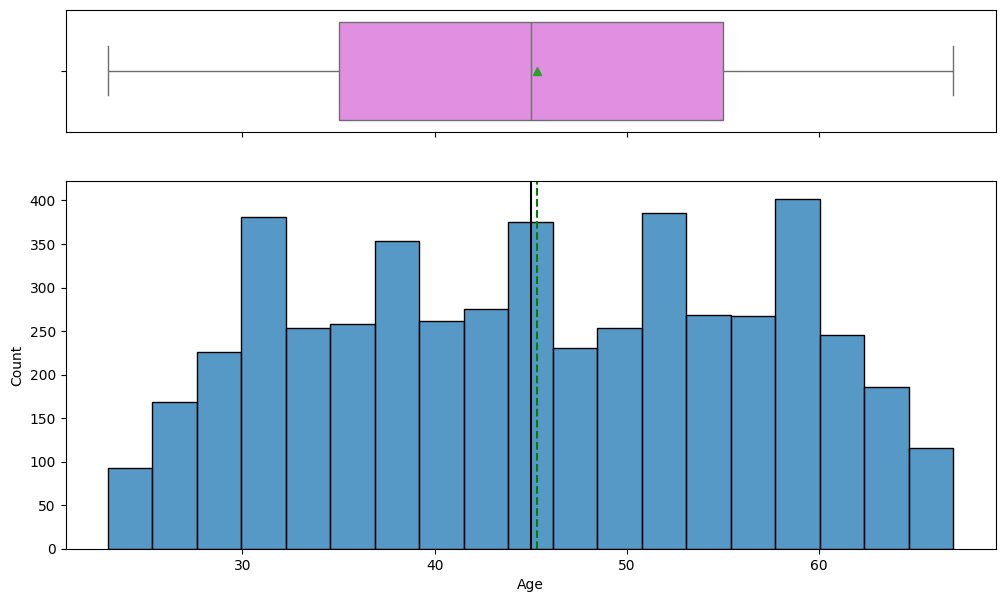

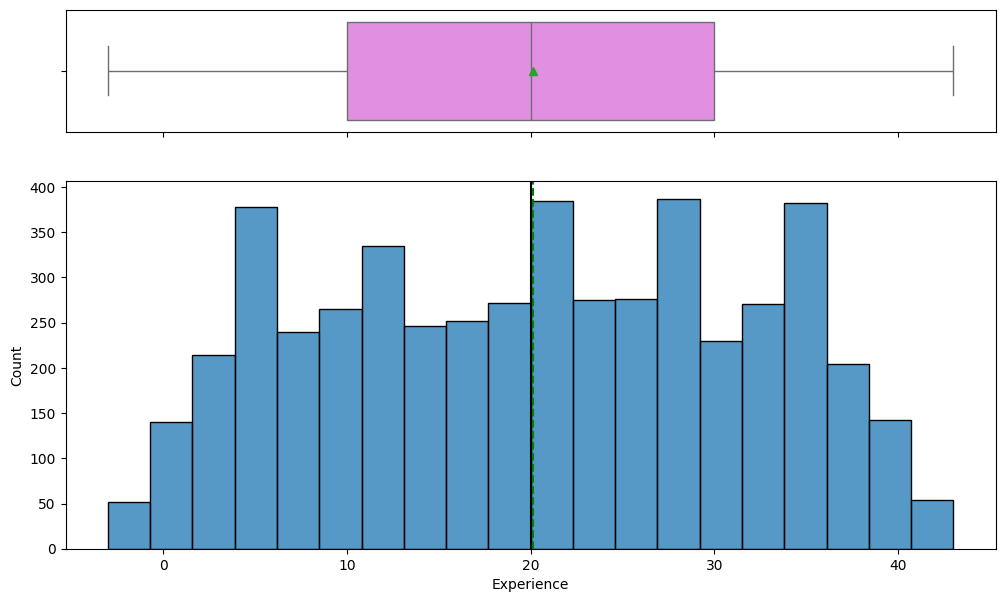

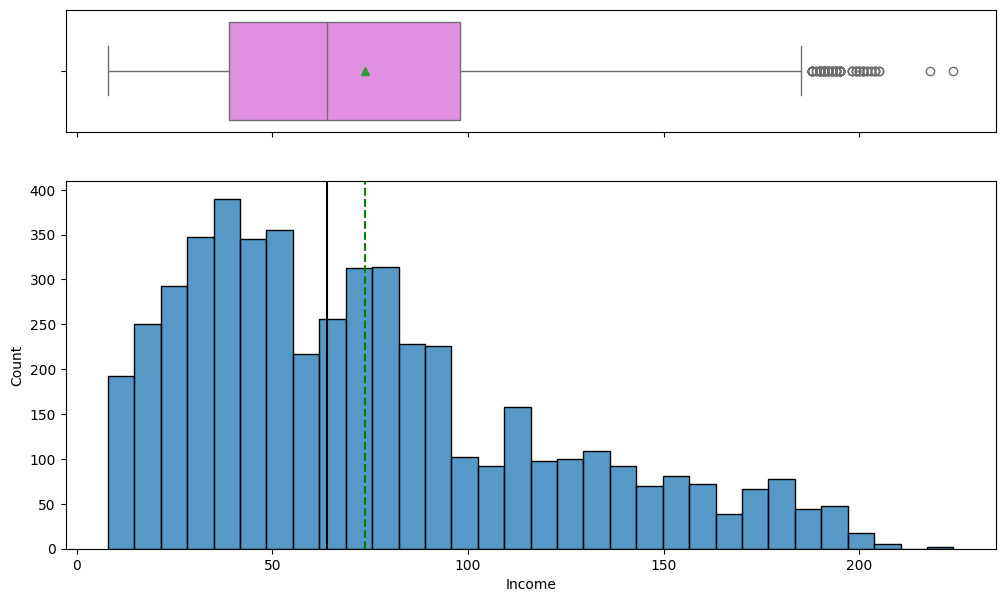

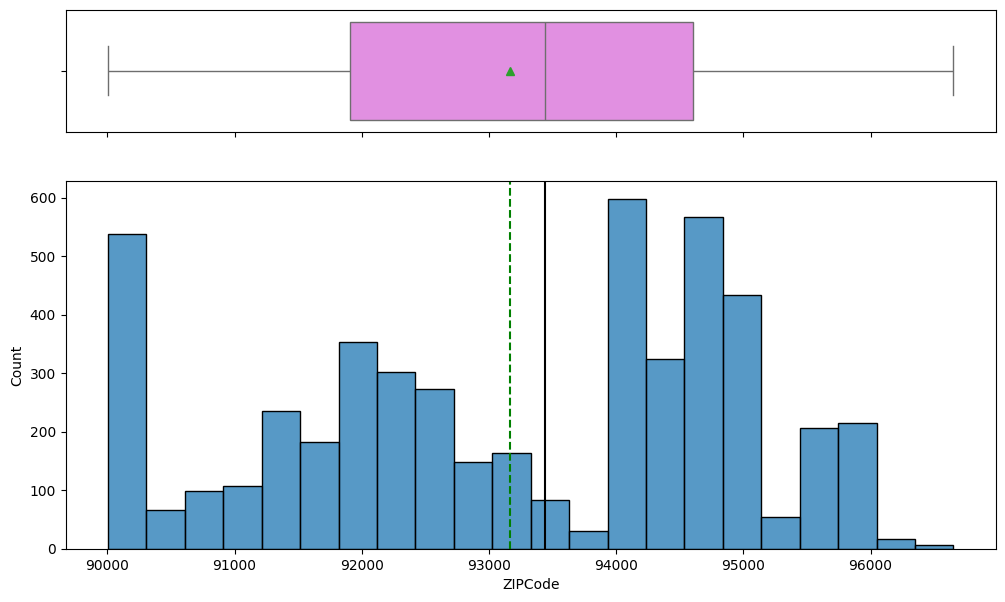

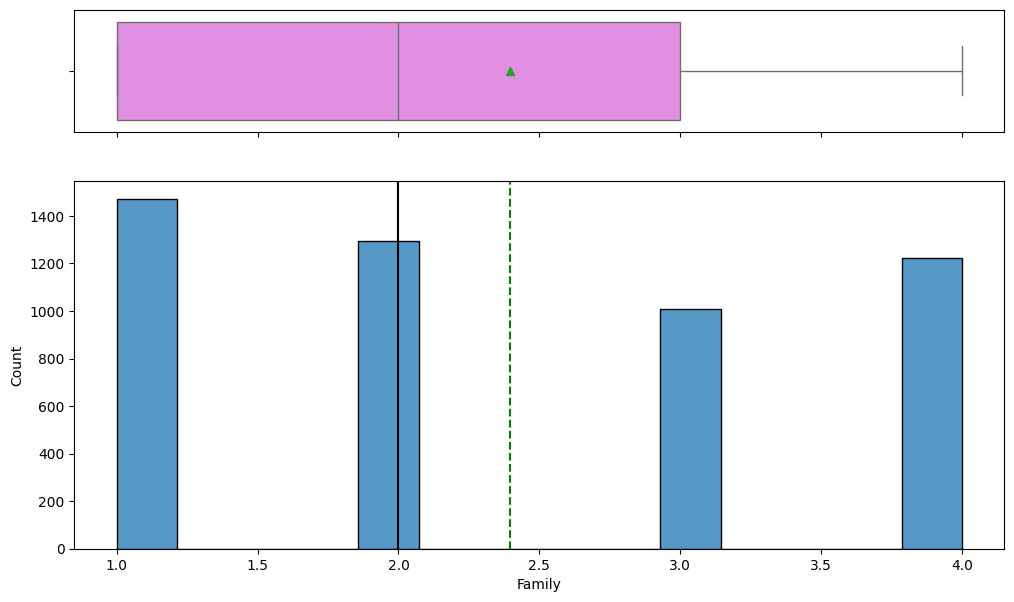

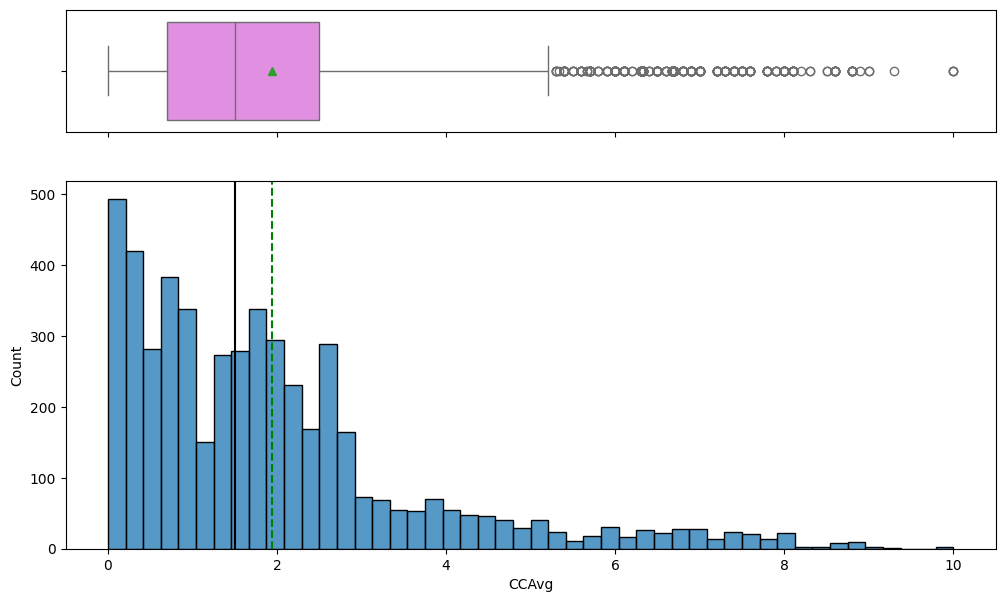

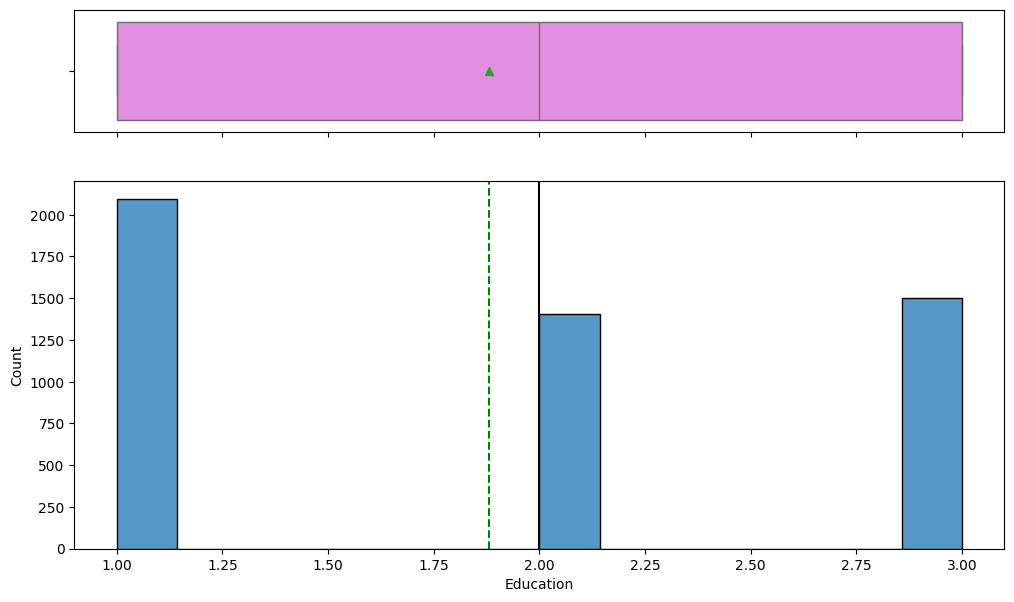

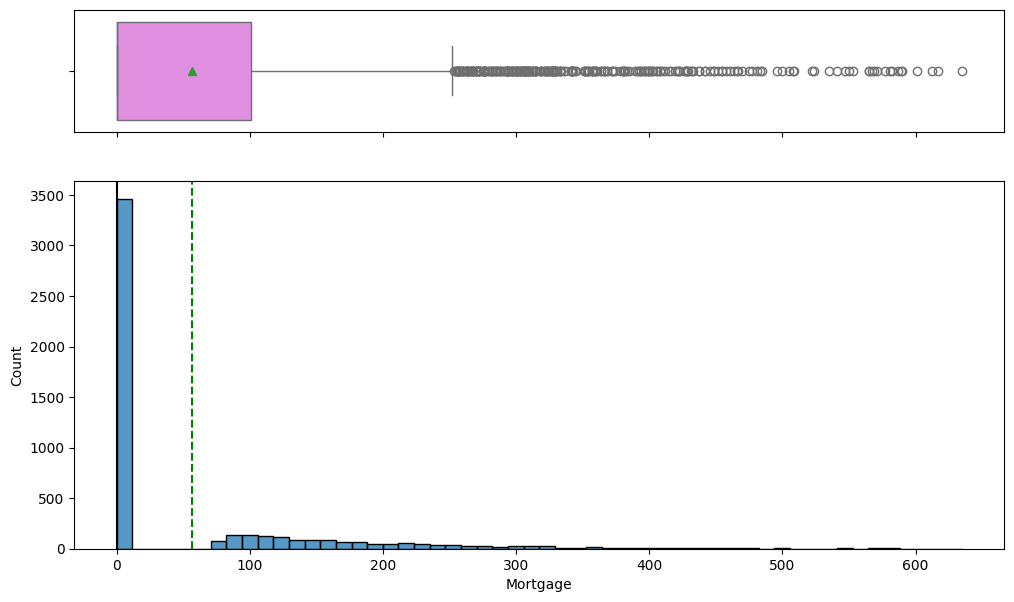

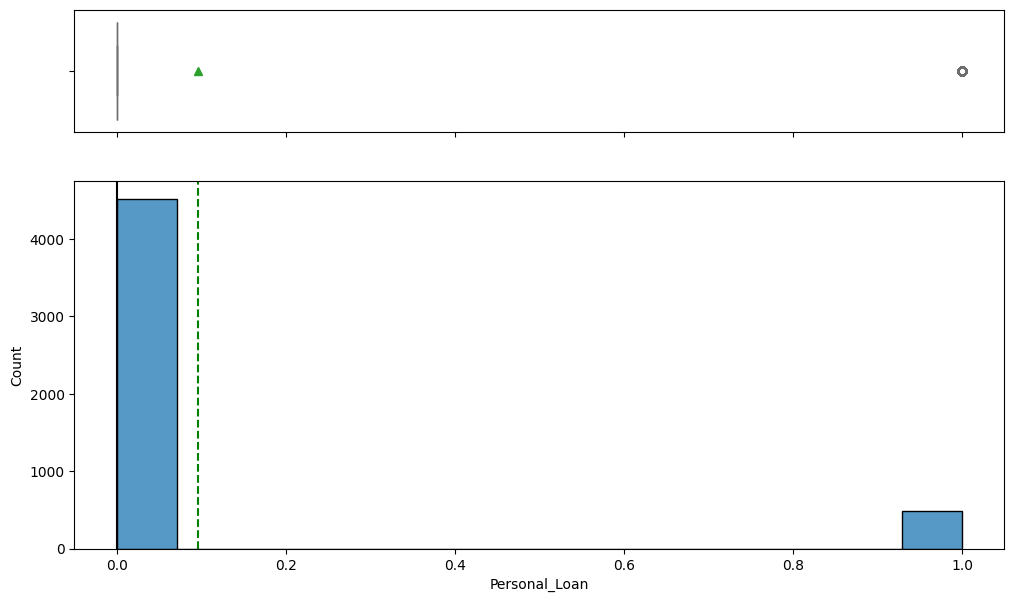

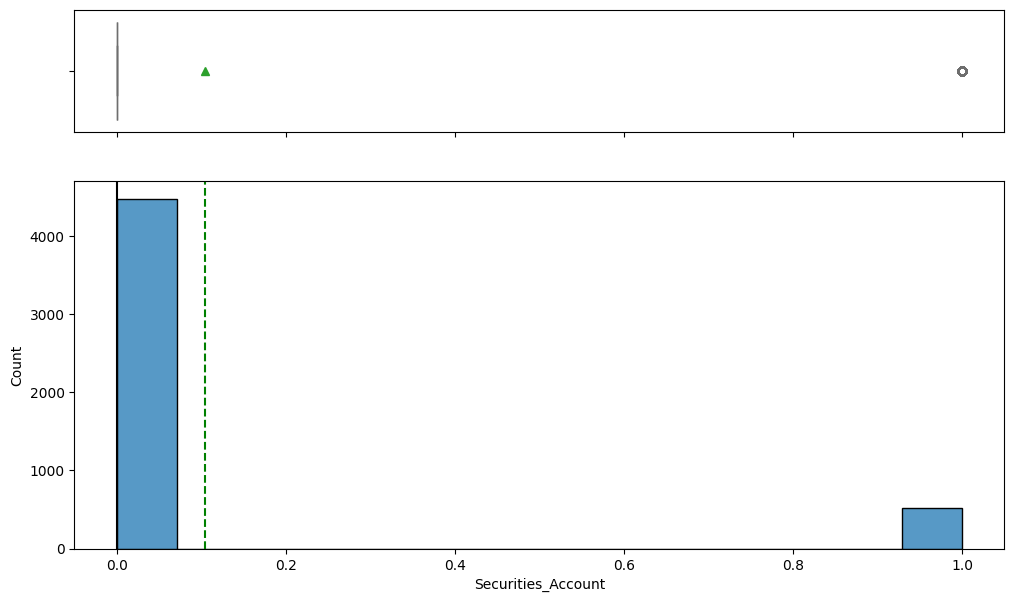

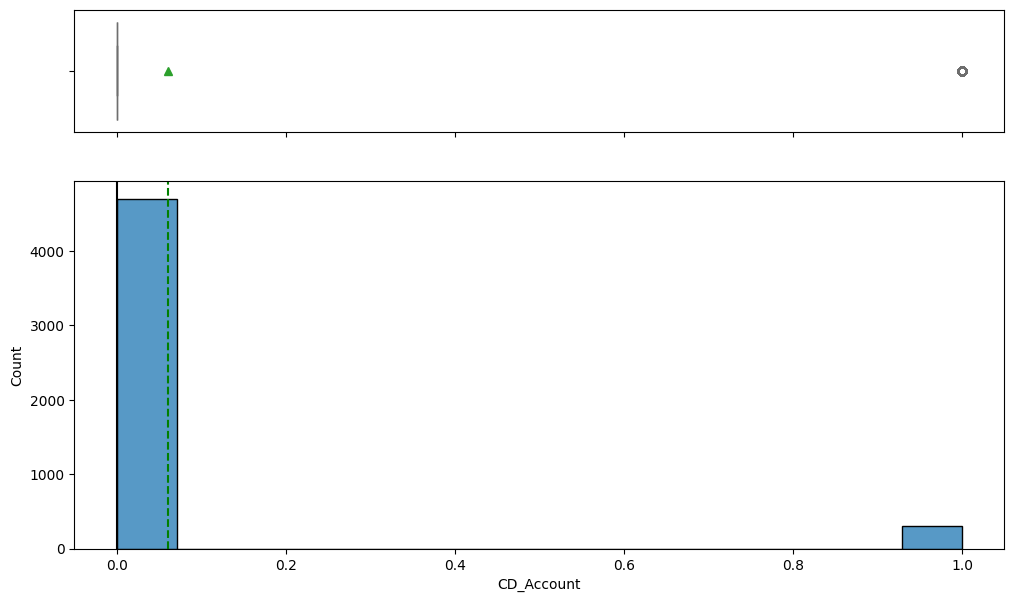

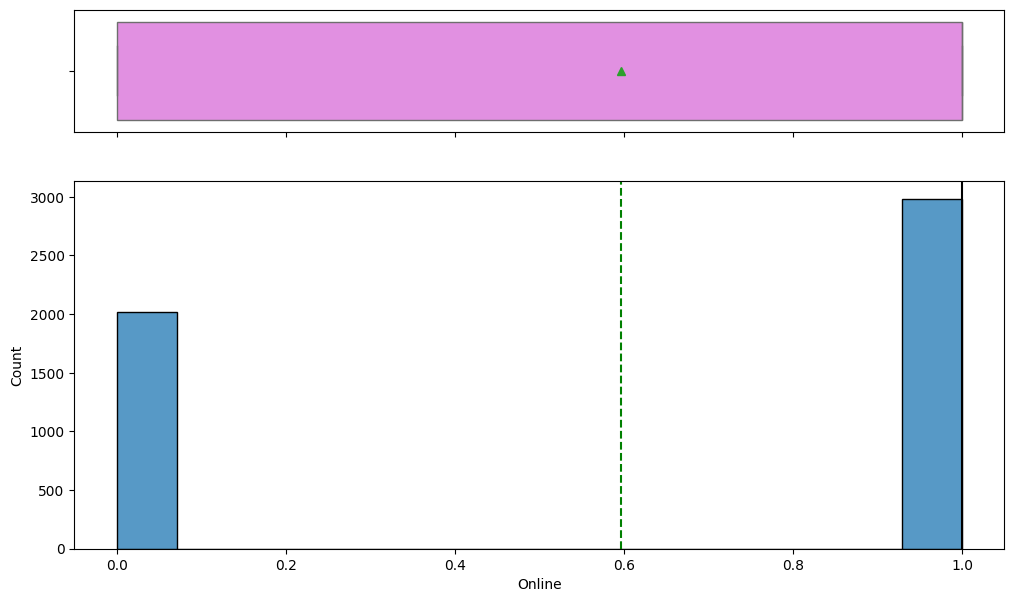

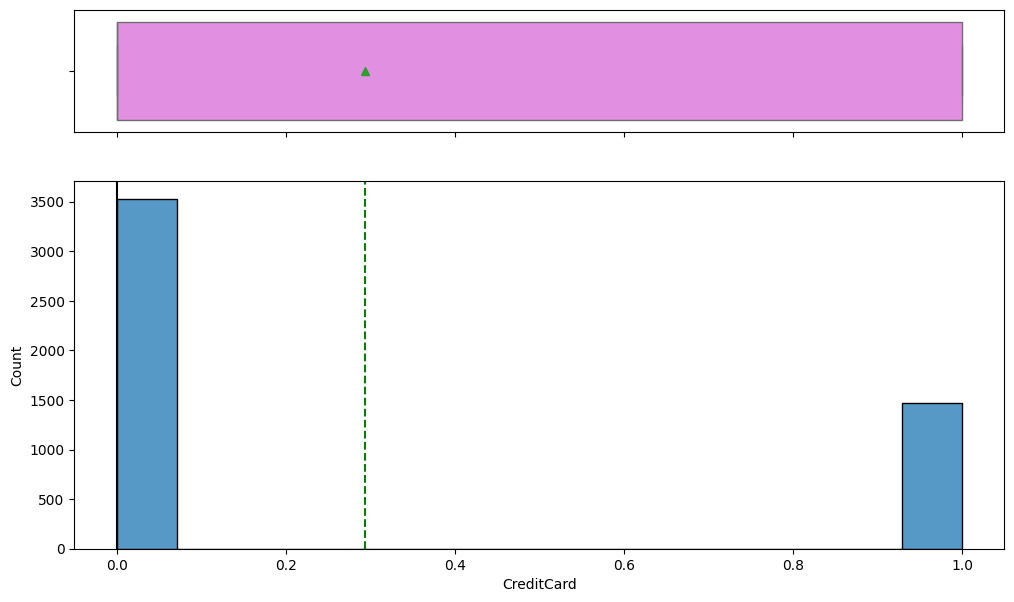

In [339]:
for col in df.columns:
    histogram_boxplot(df, col)

Observations


In [340]:
for col in df.columns.tolist()[1:]:
    labeled_barplot(df, col, perc=True)

Output hidden; open in https://colab.research.google.com to view.

**Observations**

* **Age**: The distribution of age is fairly spread out, without a strong skew. Most ages are represented, and there don't appear to be significant outliers.

* **Experience**: Similar to age, experience is also widely distributed. However, a crucial observation is the presence of negative values in 'Experience'. These are unusual and likely data entry errors or require special handling, as professional experience cannot be negative.

* **Income**: The income distribution is right-skewed, meaning a majority of customers have lower incomes, while a smaller number of customers have significantly higher incomes. The boxplot would show a concentration of data at the lower end and several outliers at the higher income levels.

* **ZIPCode**: As a geographical identifier, the distribution of ZIP codes isn't directly interpretable for numerical patterns from histograms or boxplots. It serves more as a categorical variable for location.

* **Family**: This feature shows the number of family members, typically ranging from 1 to 4. The distribution indicates the frequency of different family sizes among the customers.

* **CCAvg** (Average Credit Card Spending): This distribution is also right-skewed, indicating that most customers have relatively low monthly credit card spending. There are outliers representing customers with much higher spending.

* **Education**: This is an ordinal categorical variable (1: Undergrad, 2: Graduate, 3: Advanced/Professional). The plots would show the counts of customers in each education level, giving an idea of the educational background of the customer base.

* **Mortgage**: A significant portion of the customers have no mortgage (value 0). This results in a distribution heavily concentrated at zero, with many outliers representing customers who have substantial mortgage values.

* **Personal_Loan**: This is the target variable (0: No, 1: Yes). The univariate analysis clearly shows a severe class imbalance: a vast majority of customers (around 90.4%) did not accept the personal loan, while a small percentage (around 9.6%) did. This is a critical observation for model building.

* **Securities_Account**: Most customers (around 89.6%) do not have a securities account with the bank, indicating a skewed distribution towards '0'.

* **CD_Account** (Certificate of Deposit Account): Similarly, the majority of customers (around 93.96%) do not have a CD account, again showing a skew towards '0'.

* **Online**: A larger proportion of customers (around 59.68%) use internet banking facilities, making the '1' category more frequent than '0'.

* **CreditCard**: Less than one-third of the customers (around 29.4%) use a credit card issued by another bank, meaning the '0' category (no credit card from another bank) is more prevalent.

### Bivariate Analysis

Check for correlations.

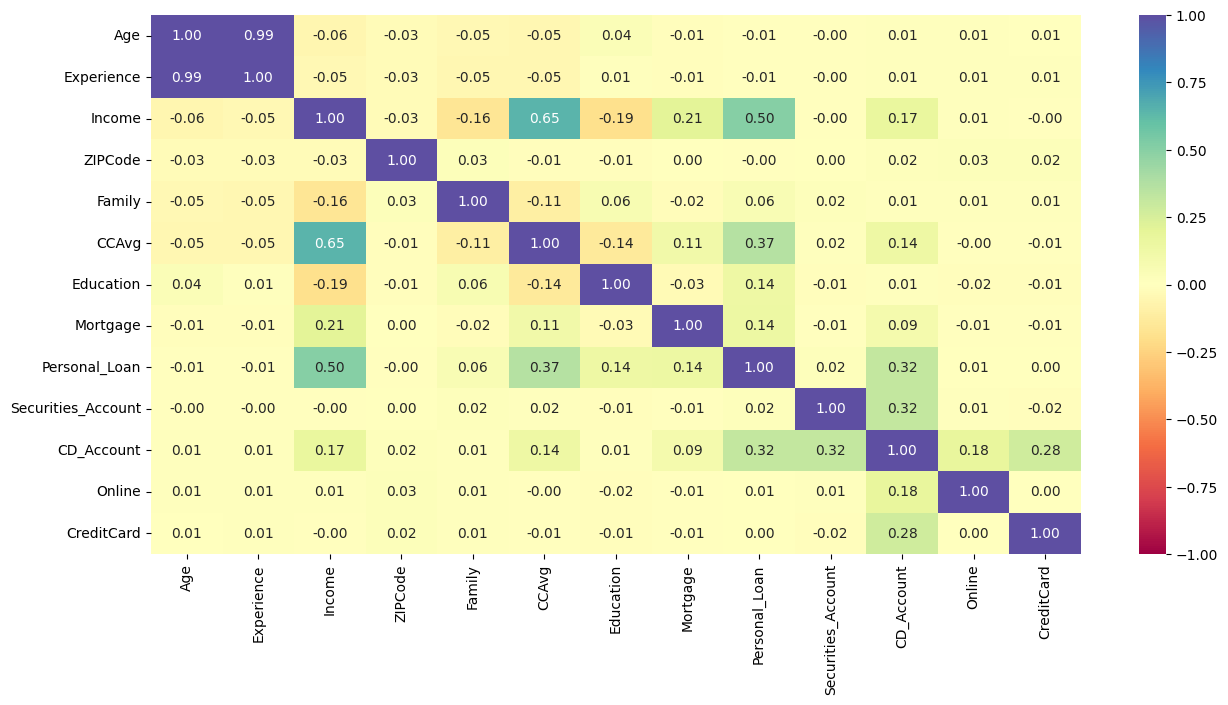

In [341]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

 **Observations**

*   **Positive Correlations:**
    *   `Age` and `Experience` are highly positively correlated (0.98). This is expected, as experience generally increases with age.
    *   `Income` shows a moderate positive correlation with `CCAvg` (0.65). Higher income customers tend to spend more on credit cards.
    *   `Personal_Loan` has a positive correlation with `Income` (0.50), `Education` (0.14), and `CD_Account` (0.32). This suggests that customers with higher income, higher education, and those who have a CD account are more likely to accept a personal loan.

*   **Negative Correlations:**
    *   `Age` and `Experience` have a slight negative correlation with `Personal_Loan`, though very small. This implies that personal loan acceptance might slightly decrease with age/experience, but it's not a strong relationship.
    *   `ZIP Code` does not show any significant correlation with other features, which is expected as it's a geographical identifier.

*   **Key Relationships for Personal Loan:**
    *   `Income` is the strongest positive predictor of `Personal_Loan` with a correlation of 0.50. This indicates that customers with higher incomes are significantly more likely to take a personal loan.
    *   `CD_Account` also has a noticeable positive correlation (0.32) with `Personal_Loan`. This means customers who already have a Certificate of Deposit account might be more inclined towards a personal loan, possibly indicating a certain financial behavior or trust in the bank.
    *   `CCAvg` shows a moderate positive correlation with `Personal_Loan` (0.37). Customers who spend more on credit cards might be more open to taking a personal loan.
    *   `Education` has a small positive correlation (0.14) with `Personal_Loan`.

*   **Other Observations:**
    *   `Securities_Account` and `CD_Account` have a moderate positive correlation (0.32), suggesting that customers who have one might also have the other.
    *   `Mortgage` has a weak positive correlation with `Income` (0.20) and `Age` (0.10).
    *   `Online` and `CreditCard` have very weak correlations with most other features, implying they are relatively independent.

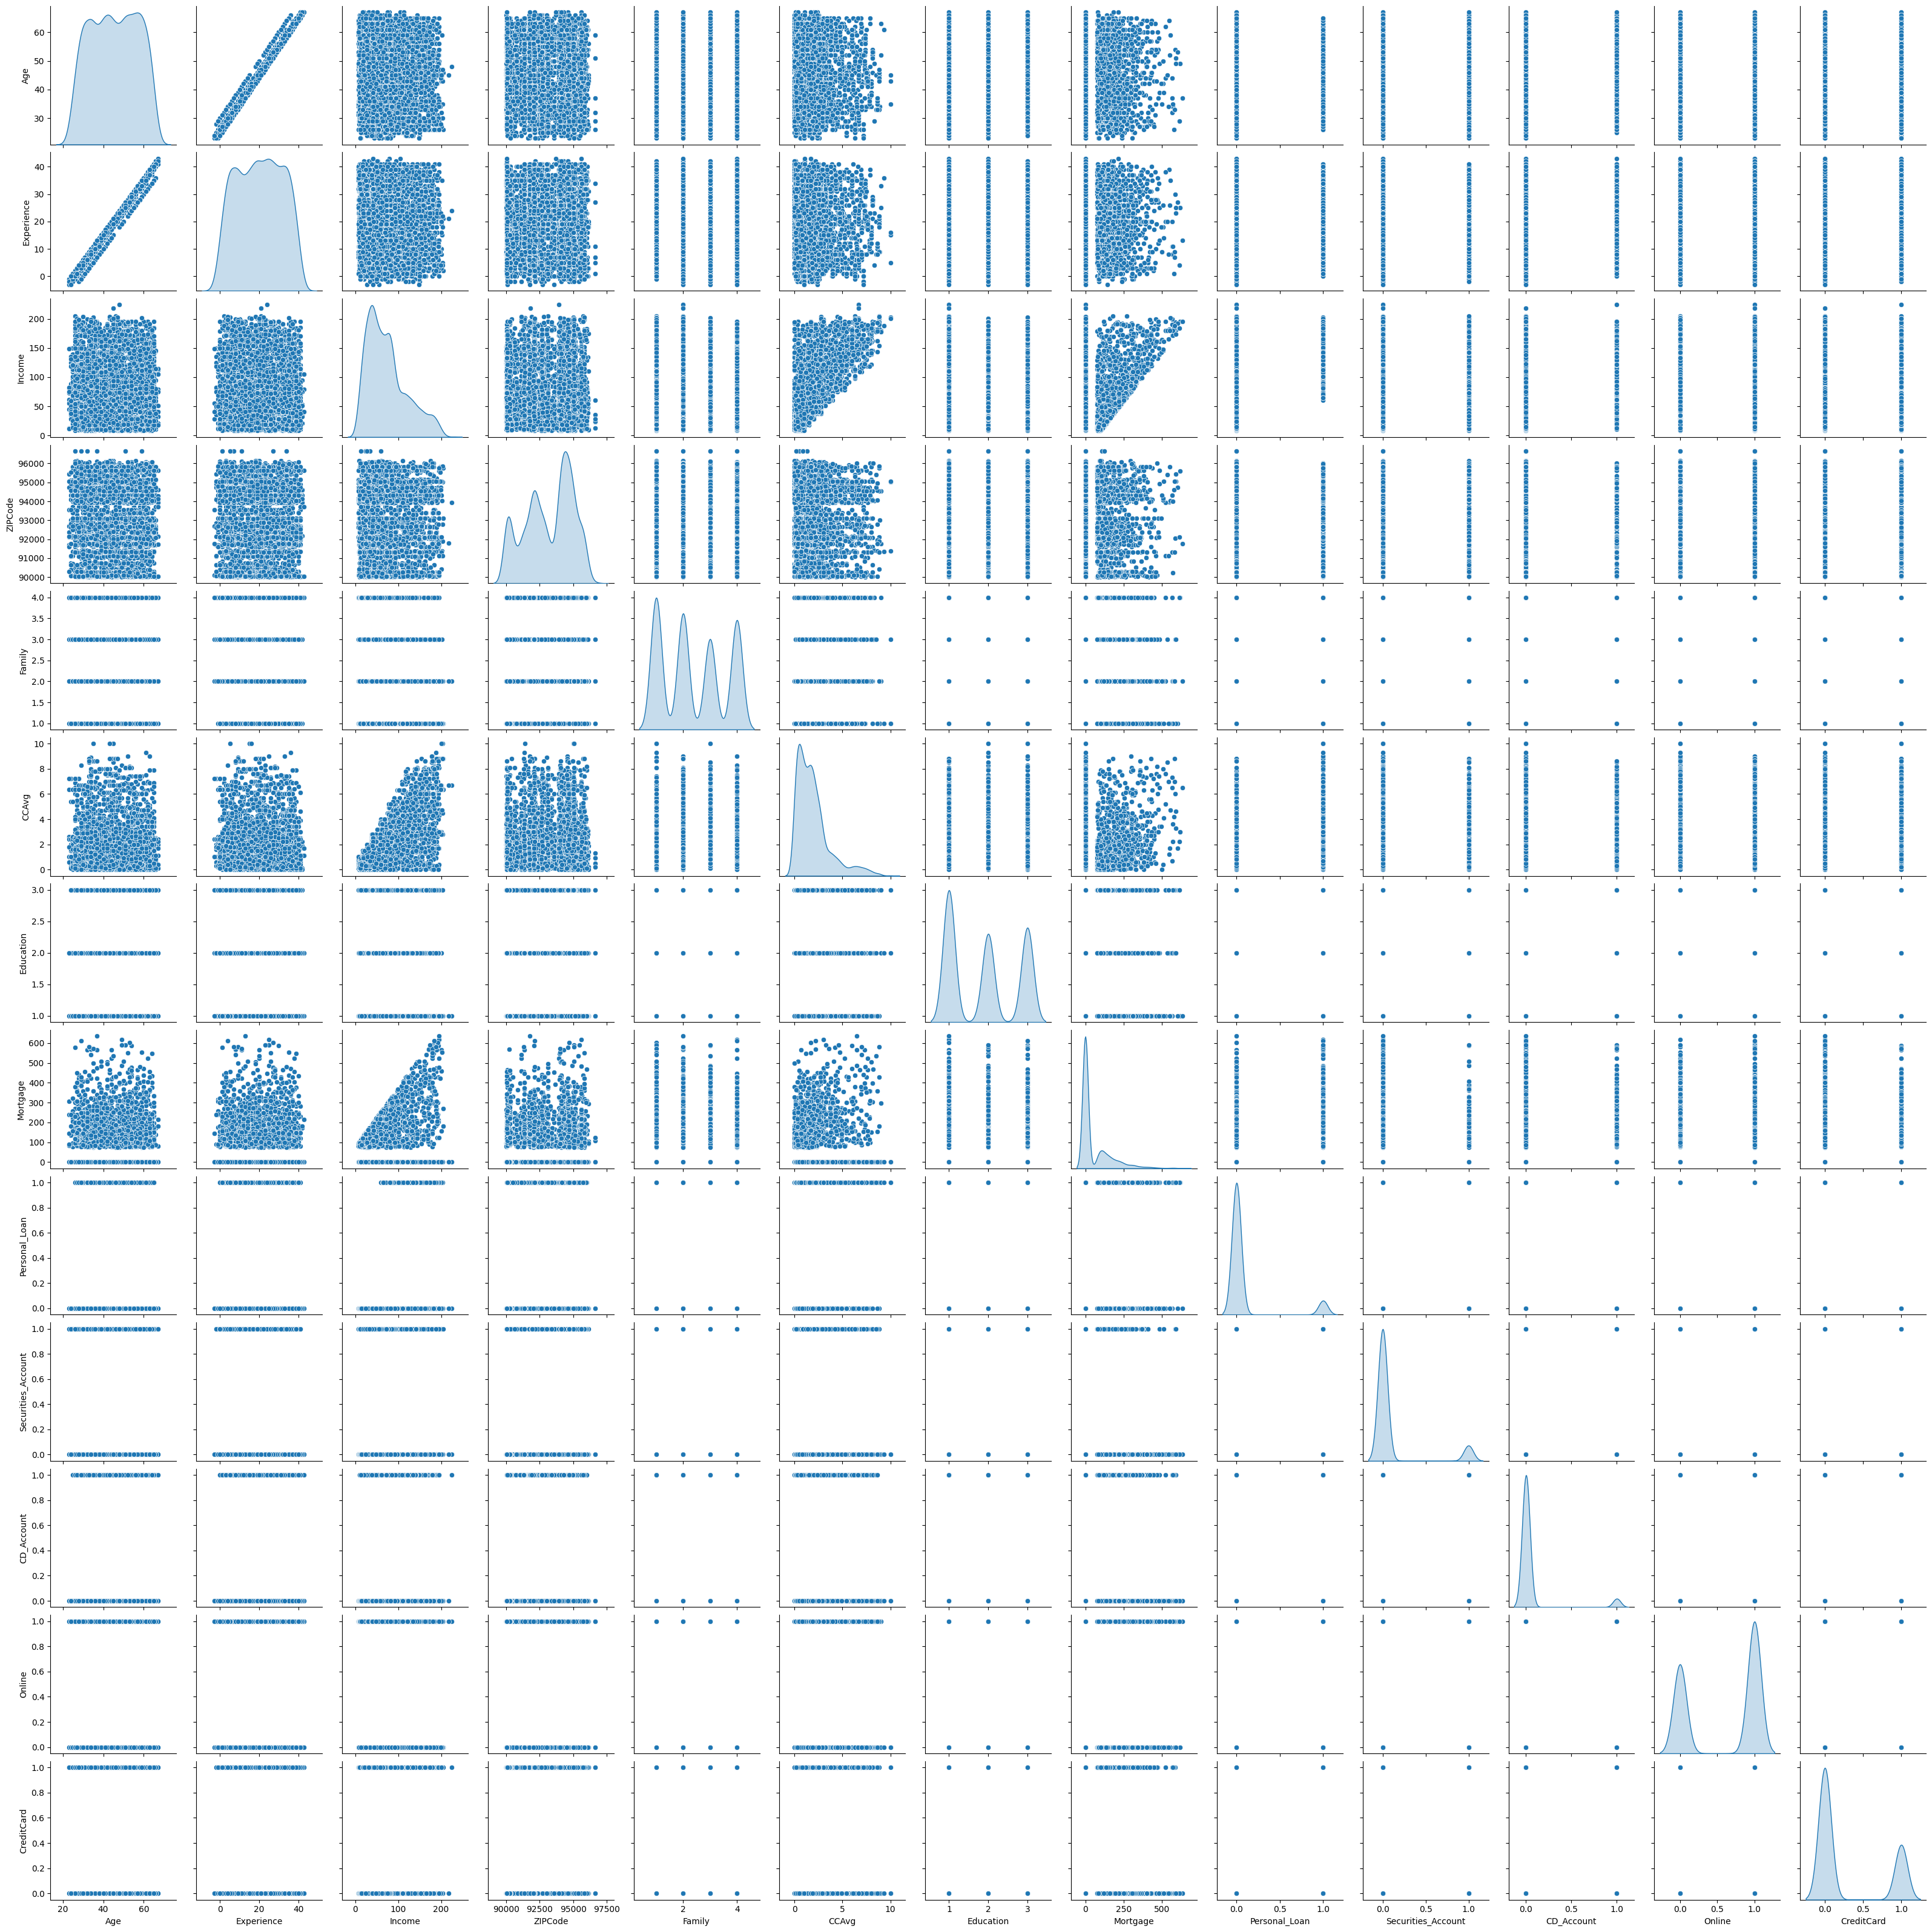

In [342]:
sns.pairplot(data=df, diag_kind="kde")
plt.show()

**Observations**
*   **Diagonal Plots (Histograms/KDEs):** These show the univariate distribution of each variable. Many distributions are skewed, for example, `Income`, `CCAvg`, and `Mortgage` are right-skewed, indicating a concentration of lower values and a tail of higher values. `Personal_Loan`, `Securities_Account`, `CD_Account`, `Online`, and `CreditCard` are binary variables, and their distributions show the proportion of 0s and 1s.

*   **Off-Diagonal Plots (Scatter Plots):** These show the bivariate relationships between pairs of variables.

    *   **Age vs. Experience:** As observed in the heatmap, there's a very strong linear relationship between `Age` and `Experience`. Most points fall along a straight line, indicating that as age increases, experience also tends to increase proportionally.

    *   **Income vs. CCAvg:** There's a positive correlation. As `Income` increases, `CCAvg` tends to increase as well, though with considerable spread.

    *   **Income vs. Personal_Loan:** This is a crucial relationship. The scatter plots (especially the one with `Income` on the x-axis and `Personal_Loan` on the y-axis, and vice-versa) reveal that customers with higher incomes are more likely to have taken a personal loan (where `Personal_Loan` = 1). The '1' dots (loan takers) are much denser at higher income levels.

    *   **Education vs. Personal_Loan:** While not as strong as income, there's a visible trend that higher `Education` levels (`1`, `2`, `3`) have a higher proportion of personal loan takers.

    *   **CCAvg vs. Personal_Loan:** Similar to income, customers with higher `CCAvg` tend to have a higher likelihood of taking a personal loan.

    *   **Other Binary Variables (Securities_Account, CD_Account, Online, CreditCard) vs. Personal_Loan:** The pair plots for these variables show the counts or distributions of personal loan acceptance within each category. For example, `CD_Account` appears to have a higher proportion of personal loan takers when `CD_Account` is 1.

*   **Insights:**
    *   The strong correlation between `Age` and `Experience` suggests that one of them might be redundant for some models or can be combined. The negative experience values also stand out here, which needs to be addressed during preprocessing.
    *   `Income`, `CCAvg`, and `Education` are the most visually impactful features in differentiating between customers who took a personal loan and those who didn't.
    *   The pair plot visually reinforces the class imbalance for `Personal_Loan`, as the points for '1' are much sparser than for '0' across all features.

## Questions



### Question 1
What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

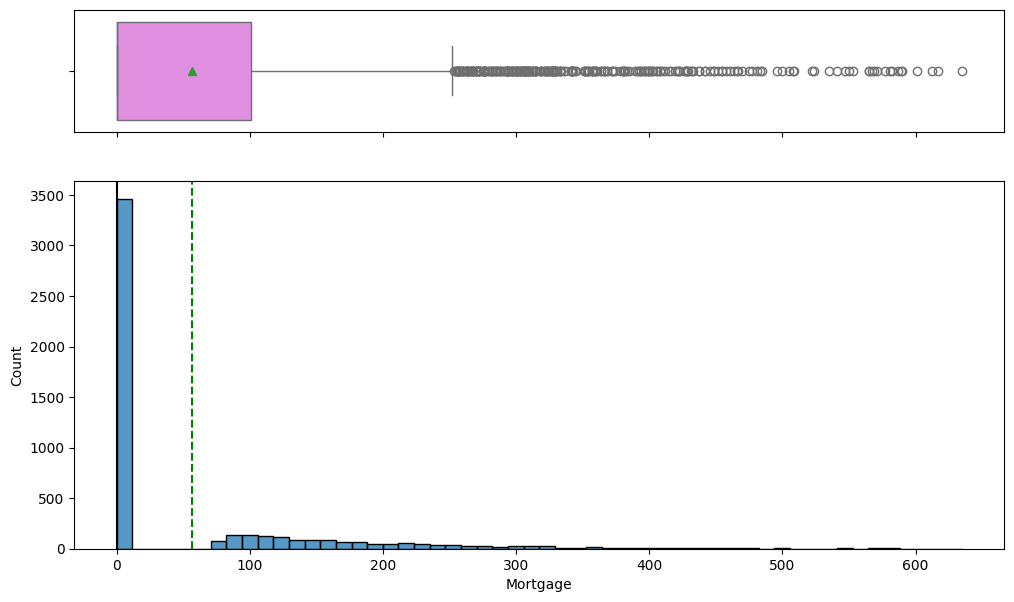

In [343]:
histogram_boxplot(df, 'Mortgage')

 **Observations:**

*   The distribution of `Mortgage` is highly right-skewed, with a large concentration of values at 0. This indicates that a significant portion of customers do not have a mortgage.
*   There are many outliers on the higher end, suggesting that some customers have very substantial mortgage values. The maximum mortgage value is 635 (in thousand dollars), which is considerably higher than the median of 0.
*   The boxplot clearly shows the majority of data points clustered around 0, and a long tail extending to the right with many individual points indicating outliers.

### Question 2
How many customers have credit cards?

In [344]:
num_credit_card_customers = df['CreditCard'].value_counts()[1]
print(f"Number of customers with credit cards: {num_credit_card_customers}")

Number of customers with credit cards: 1470


### Question 3
What are the attributes that have a strong correlation with the target attribute (personal loan)?

Based on the heatmap and pair plot observations:

*   **`Income`**: Shows the strongest positive correlation with `Personal_Loan` (0.50). This indicates that customers with higher incomes are significantly more likely to accept a personal loan.

*   **`CCAvg`**: Has a moderate positive correlation with `Personal_Loan` (0.37). Customers with higher average credit card spending tend to have a higher likelihood of taking a personal loan.

*   **`CD_Account`**: Exhibits a noticeable positive correlation with `Personal_Loan` (0.32). Customers who already possess a Certificate of Deposit (CD) account might be more inclined towards a personal loan, possibly reflecting a certain financial behavior or existing trust in the bank.

*   **`Education`**: Shows a small but positive correlation with `Personal_Loan` (0.14). Higher education levels are associated with a slightly increased propensity to take a personal loan.

### Question 4
How does a customer's interest in purchasing a loan vary with their age?

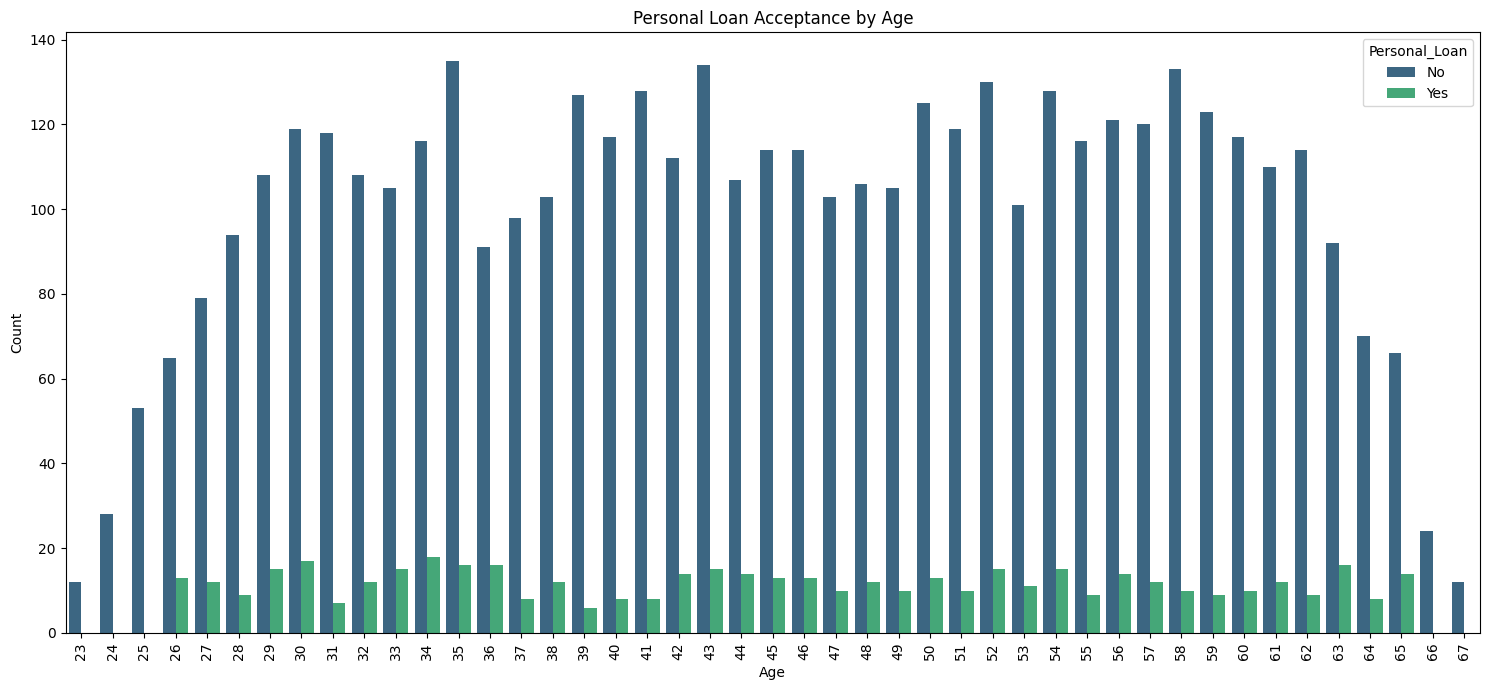

In [345]:
### Personal Loan Acceptance by Age
plt.figure(figsize=(15, 7))
sns.countplot(data=df, x='Age', hue='Personal_Loan', palette='viridis')
plt.title('Personal Loan Acceptance by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Personal_Loan', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

 **Observations :**

*   The plot shows the count of customers who did (Personal_Loan = 1) and did not (Personal_Loan = 0) accept a personal loan across different age groups.
*   It appears that across all age groups, the number of customers who did *not* accept a personal loan significantly outweighs those who did. This is consistent with the overall class imbalance observed earlier.
*   While there isn't a stark linear increase or decrease in loan acceptance with age, we can observe that the proportion of customers taking a loan seems to be somewhat consistent across different age bands.
*   There is no clear age group that stands out as having a disproportionately high interest in personal loans compared to other age groups, at least not in absolute numbers. To get a better sense of *proportion*, we might need a stacked bar chart showing percentages or a ratio plot.

### Question 5
How does a customer's interest in purchasing a loan vary with their education?

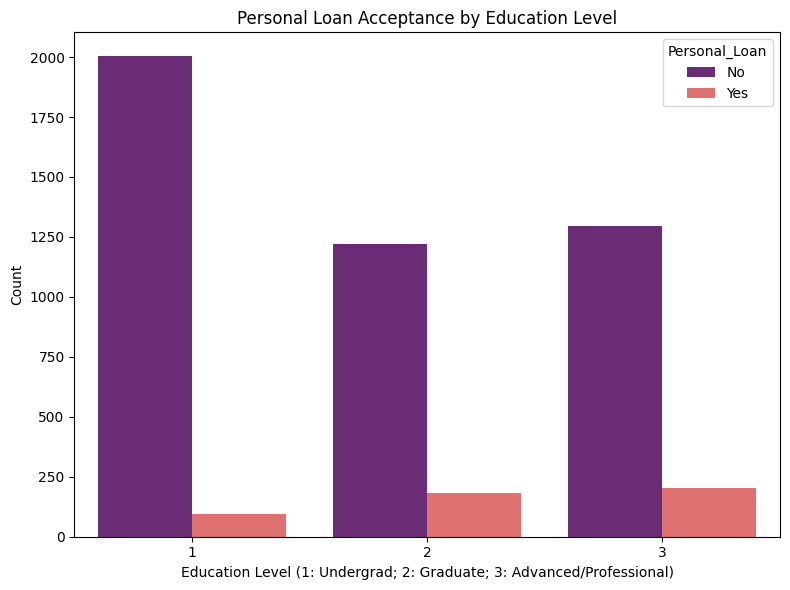

In [346]:
### Personal Loan Acceptance by Education
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Education', hue='Personal_Loan', palette='magma')
plt.title('Personal Loan Acceptance by Education Level')
plt.xlabel('Education Level (1: Undergrad; 2: Graduate; 3: Advanced/Professional)')
plt.ylabel('Count')
plt.legend(title='Personal_Loan', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

 **Observations:**

*   The plot shows the number of customers who did and did not accept a personal loan across the three education levels.
*   Consistent with the overall dataset, the number of customers who did *not* accept a personal loan significantly outweighs those who did, across all education levels.
*   However, by looking at the proportions, it appears that customers with higher education levels (especially `Education` level 3: Advanced/Professional) tend to have a relatively higher proportion of personal loan acceptance compared to those with lower education levels.
*   This supports the weak positive correlation observed in the heatmap, suggesting that education is a factor, albeit not as strong as income, in predicting personal loan uptake.

## Data Preprocessing
* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

### Missing Value treatment

In [347]:
#Replace all negative values in the 'Experience' column with np.nan (Not a Number) to mark them as missing data, as professional experience cannot be negative. This prepares the data for appropriate missing value treatment.
df.loc[df['Experience'] < 0, 'Experience'] = 0
print(f"Number of NaN values in 'Experience' column after replacement: {df['Experience'].isnull().sum()}")
# confirm the change and show a summary of the 'Experience' column after replacing negative values with NaN, I will display its descriptive statistics.

df['Experience'].describe().T

Number of NaN values in 'Experience' column after replacement: 0


,Experience
count,5000.000000
mean,20.119600
std,11.440484
min,0.000000
25%,10.000000
50%,20.000000
75%,30.000000
max,43.000000


* We will also drop the ZIPCode as it has 0 corelation with the Personal_Loan (performed EDA and then decided to drop this column)

In [348]:
df.drop(columns=["ZIPCode"], inplace=True)

### Outlier detection

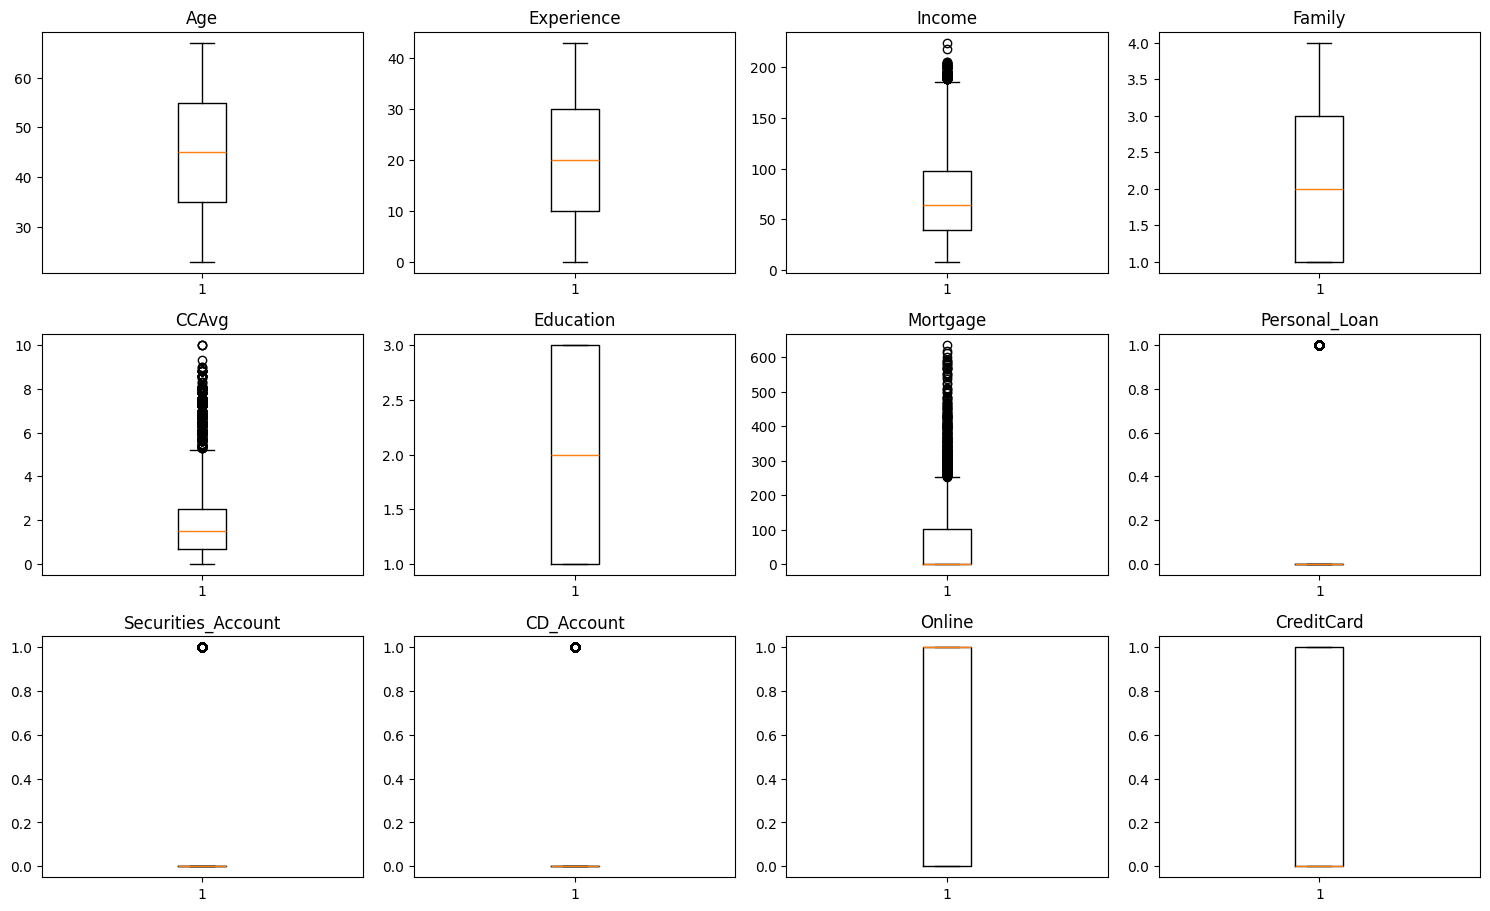

In [349]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Observations

* There are quite a few outliers in the data.
* However, we will not treat them as they are proper values

### Data Preparation for Modeling

In [350]:
X = df.drop(["Personal_Loan"], axis=1)
Y = df["Personal_Loan"]

X = pd.get_dummies(X, drop_first=True)

X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 11)
Shape of test set :  (1500, 11)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


* Around 90% of observations belongs to class 0 (Personal Loan - No) and 10% observations belongs to class 1 (Personal Loan - Yes), and this is preserved in the train and test sets

## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**
- Predicting a customer will not accpet personal loan but in reality, the customer accepts (FN)
- Predicting a customer will accept personal loan but in reality, the customer does not accept (FP)

**Which case is more important?**

- If we predict that a customer will not accpet personal loan but in reality, the customer would have accepted, the bank misses profit from interest and fees and lost some revenue.
- If we predict that a customer will accept personal loan but in reality, the customer does not accept then bank will face some cost (e.g., marketing email, ad, or agent time), but not a financial loss on the loan side.


**How to reduce the losses?**

The bank would want to minimize the False Negatives.
The bank would want the recall to be maximized, greater the recall score higher are the chances of minimizing the False Negatives.

In [351]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [352]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Decision Tree (default)

In [353]:
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

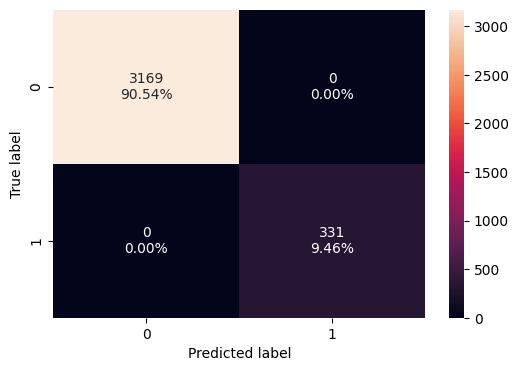

In [354]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [355]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


In [356]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.98,0.885906,0.910345,0.897959


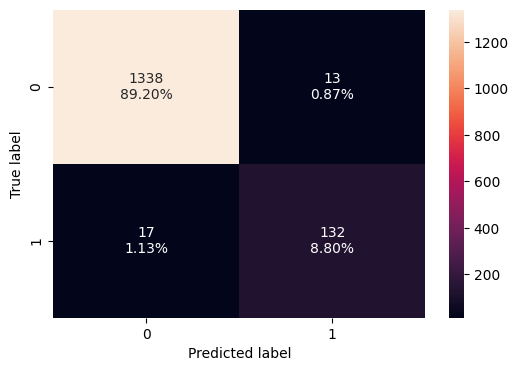

In [357]:
confusion_matrix_sklearn(model0, X_test, y_test)

### Decision Tree (with class_weights)

In [358]:
model1 = DecisionTreeClassifier(random_state=1, class_weight="balanced")
model1.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

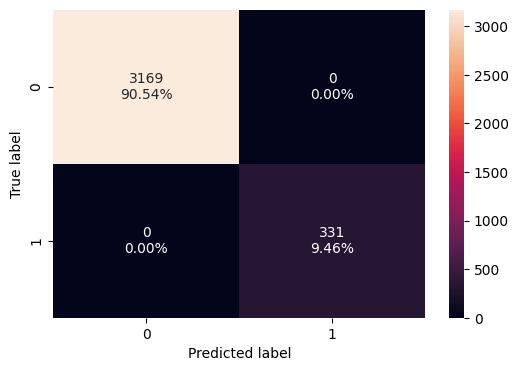

In [359]:
confusion_matrix_sklearn(model1, X_train, y_train)

In [360]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model1, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


* Model is able to perfectly classify all the data points on the training set.
* 0 errors on the training set, each sample has been classified correctly.
* As we know a decision tree will continue to grow and classify each data point correctly if no restrictions are applied as the trees will learn all the patterns in the training set.
* This generally leads to overfitting of the model as Decision Tree will perform well on the training set but will fail to replicate the performance on the test set.

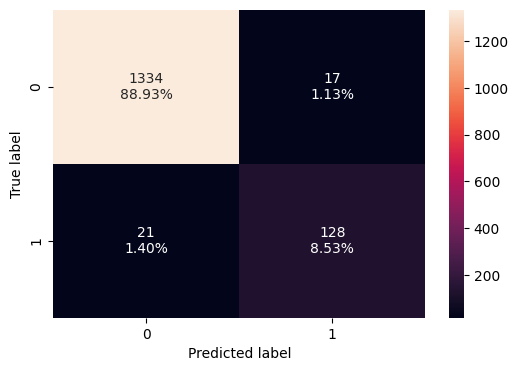

In [361]:
confusion_matrix_sklearn(model1, X_test, y_test)

In [362]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model1, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.974667,0.85906,0.882759,0.870748


* There is a huge disparity in performance of model on training set and test set, which suggests that the model is overfiiting.

**Let's use pruning techniques to try and reduce overfitting.**

### Decision Tree (Pre-pruning)

* Hyperparameter tuning is crucial because it directly affects the performance of a model.
* Unlike model parameters which are learned during training, hyperparameters need to be set before training.
* Effective hyperparameter tuning helps in improving the performance and robustness of the model.
* The below custom loop for hyperparameter tuning iterates over predefined parameter values to identify the best model based on the metric of choice (recall score).

In [364]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(3, 7, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate recall scores for training and test sets
            train_recall_score = recall_score(y_train, y_train_pred)
            test_recall_score = recall_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_recall_score - test_recall_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall_score
                best_estimator = estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

Best parameters found:
Max depth: 3
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 0.9328859060402684


In [365]:
# creating an instance of the best model
model2 = best_estimator

# fitting the best model to the training data
model2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(3),
                       max_leaf_nodes=50, min_samples_split=10,
                       random_state=42)

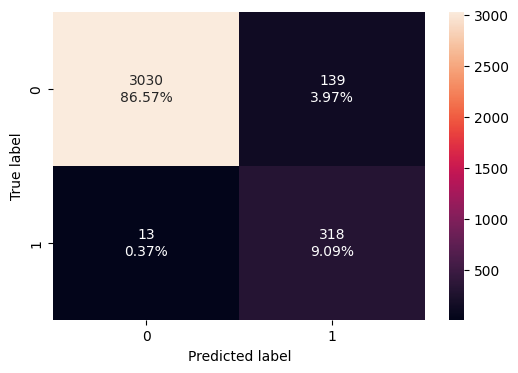

In [366]:
confusion_matrix_sklearn(model2, X_train, y_train)

In [367]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    model2, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.956571,0.960725,0.695842,0.807107


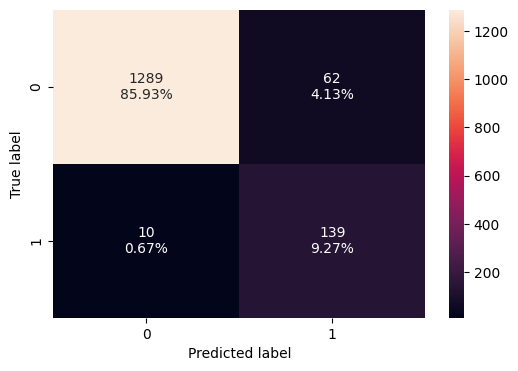

In [368]:
confusion_matrix_sklearn(model2, X_test, y_test)

In [369]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    model2, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.952,0.932886,0.691542,0.794286


* The model is giving a generalized result now since the recall scores on both the train and test data are coming to be around 1 which shows that the model is able to generalize well on unseen data.

In [370]:
feature_names = list(X_train.columns)
importances = model2.feature_importances_
indices = np.argsort(importances)

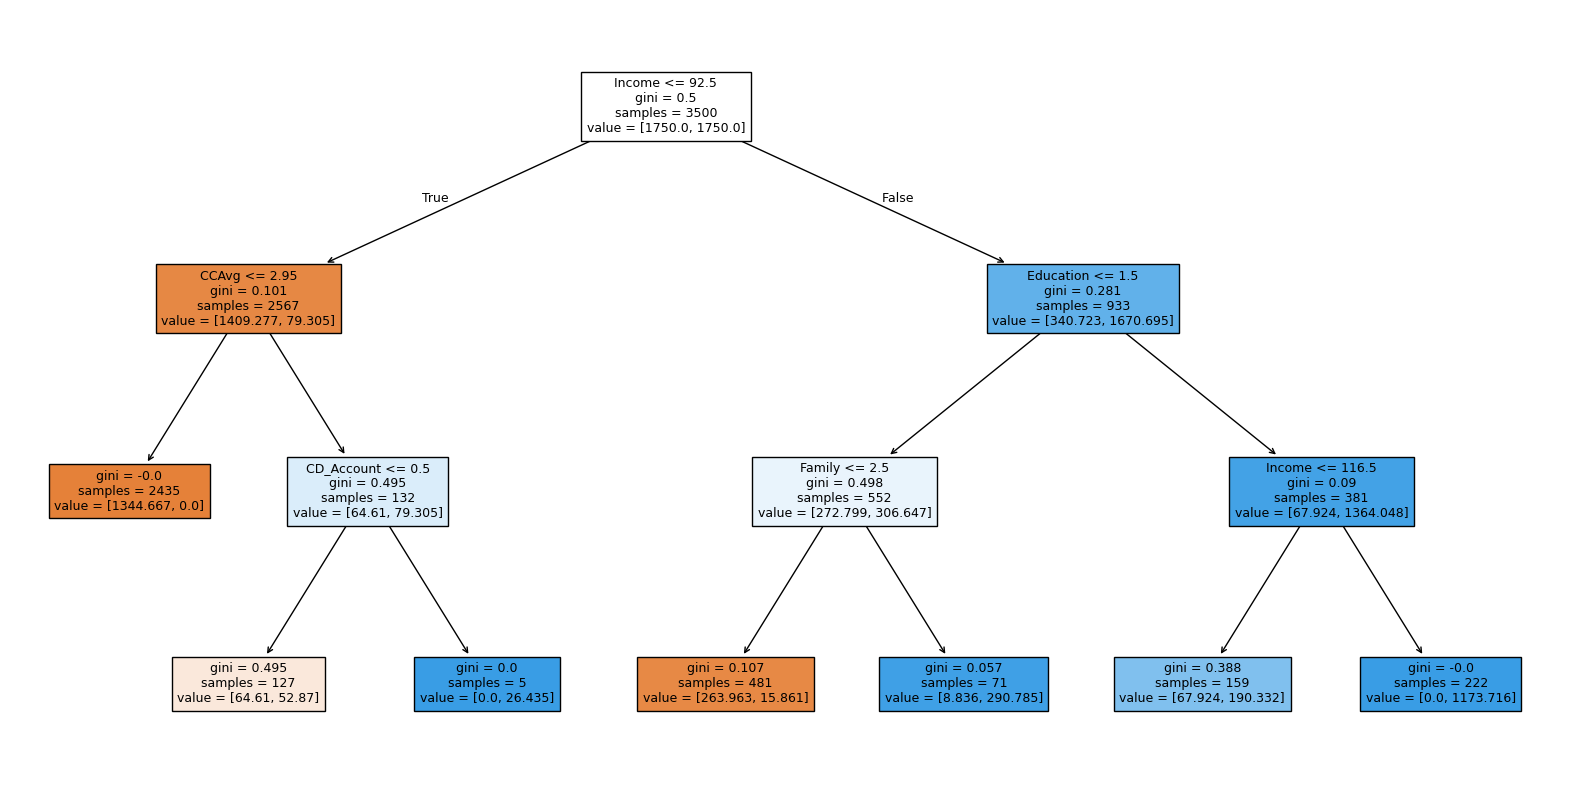

In [371]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    model2,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [372]:
# Text report showing the rules of a decision tree -
print(tree.export_text(model2, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- weights: [64.61, 52.87] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [0.00, 26.44] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [263.96, 15.86] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [8.84, 290.79] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 116.50
|   |   |   |--- weights: [67.92, 190.33] class: 1
|   |   |--- Income >  116.50
|   |   |   |--- weights: [0.00, 1173.72] class: 1



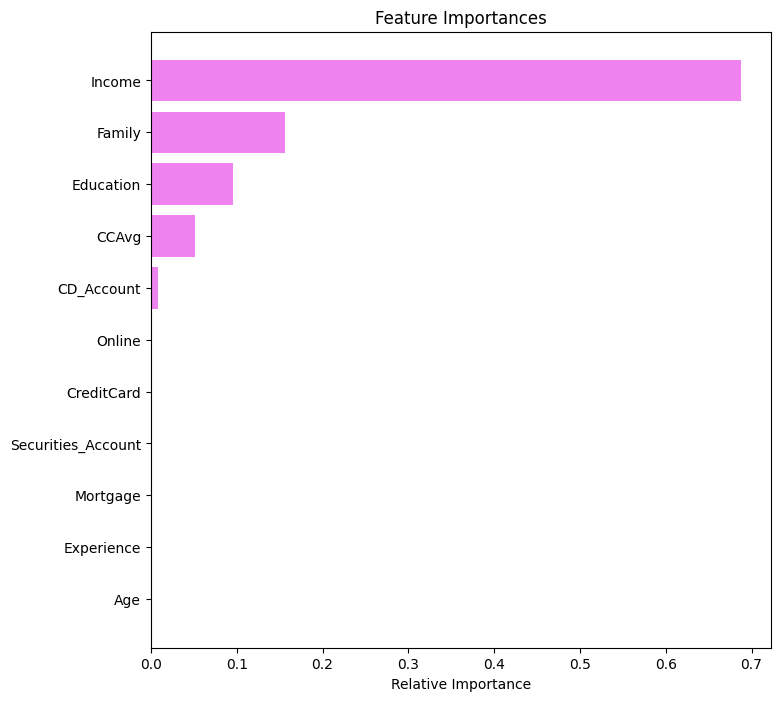

In [373]:
# importance of features in the tree building

importances = model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Income is most important feature according to pre pruning. Other important feature are Family, Education, CCAvg, CD_Account.

### Decision Tree (Post pruning)

- Cost complexity pruning provides another option to control the size of a tree.
- In `DecisionTreeClassifier`, this pruning technique is parameterized by the
cost complexity parameter, ``ccp_alpha``.
- Greater values of ``ccp_alpha`` increase the number of nodes pruned.
- Here we only show the effect of ``ccp_alpha`` on regularizing the trees and how to choose the optimal ``ccp_alpha`` value.

**Total impurity of leaves vs effective alphas of pruned tree**

Minimal cost complexity pruning recursively finds the node with the "weakest
link". The weakest link is characterized by an effective alpha, where the
nodes with the smallest effective alpha are pruned first. To get an idea of
what values of ``ccp_alpha`` could be appropriate, scikit-learn provides
`DecisionTreeClassifier.cost_complexity_pruning_path` that returns the
effective alphas and the corresponding total leaf impurities at each step of
the pruning process. As alpha increases, more of the tree is pruned, which
increases the total impurity of its leaves.

In [374]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [375]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,-1.940128e-15
1,3.853725e-19,-1.939743e-15
2,3.853725e-19,-1.939357e-15
3,3.853725e-19,-1.938972e-15
4,4.729571e-19,-1.938499e-15
5,5.255079e-19,-1.937974e-15
6,7.006772e-19,-1.937273e-15
7,1.051016e-18,-1.936222e-15
8,1.257806e-17,-1.923644e-15
9,1.524700e-04,3.049400e-04


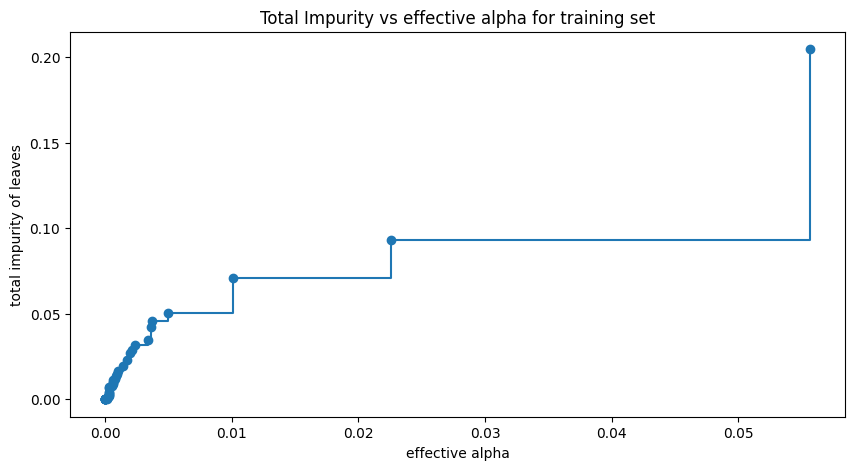

In [376]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using the effective alphas. The last value
in ``ccp_alphas`` is the alpha value that prunes the whole tree,
leaving the tree, ``clfs[-1]``, with one node.

In [377]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.29537927599923264


For the remainder, we remove the last element in
``clfs`` and ``ccp_alphas``, because it is the trivial tree with only one
node. Here we show that the number of nodes and tree depth decreases as alpha
increases.

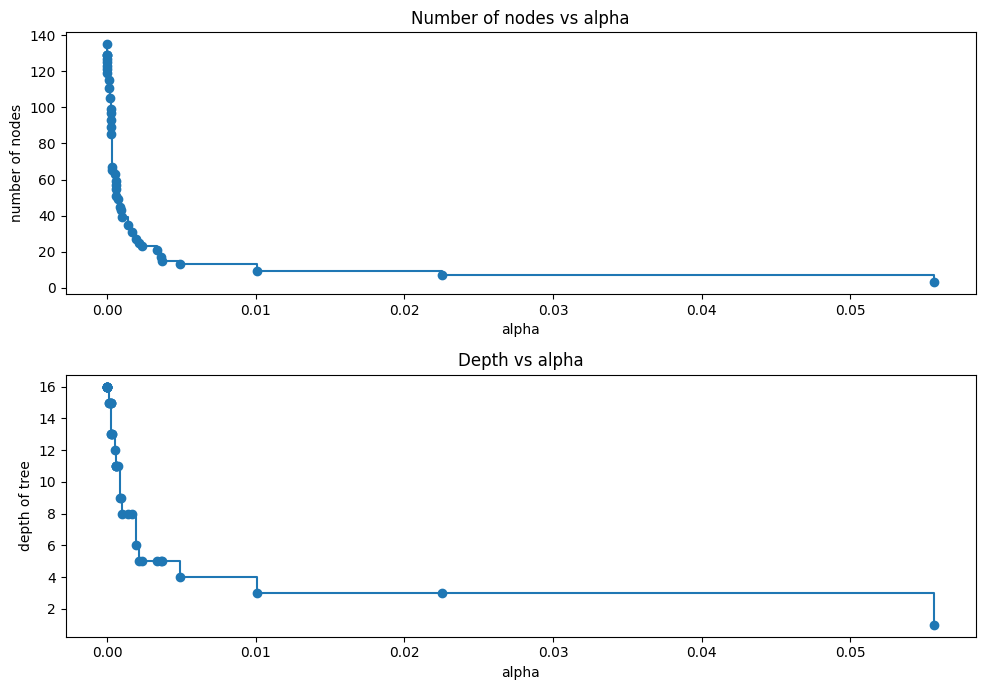

In [378]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [379]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [380]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [381]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

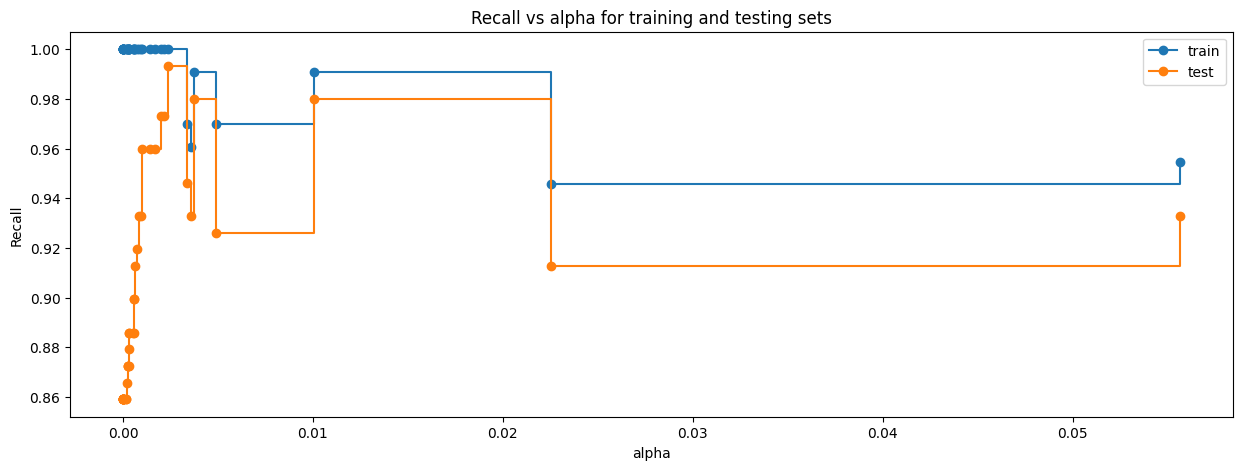

In [383]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [384]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.002375808619774645),
                       class_weight='balanced', random_state=1)


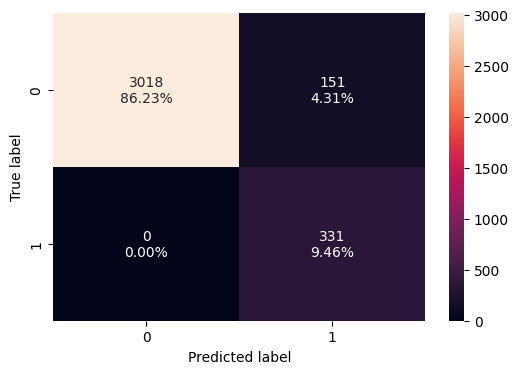

In [385]:
model4 = best_model
confusion_matrix_sklearn(model4, X_train, y_train)

In [386]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    model4, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.956857,1.0,0.686722,0.814268


In [387]:
decision_tree_post_test = model_performance_classification_sklearn(
    model4, X_test, y_test
)
decision_tree_post_test

,Accuracy,Recall,Precision,F1
0,0.948667,0.993289,0.660714,0.793566


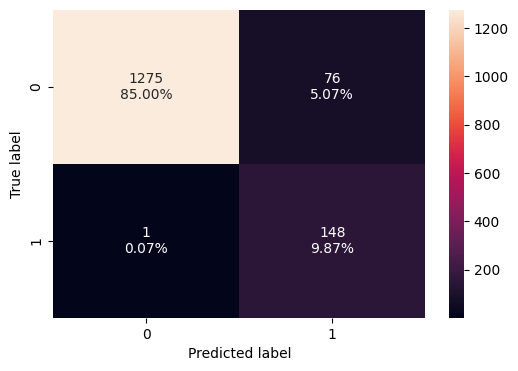

In [388]:
confusion_matrix_sklearn(model4, X_test, y_test)

* In the post-pruned tree also, the model is giving a generalized result since the recall scores on both the train and test data are coming to be around 1 which shows that the model is able to generalize well on unseen data.

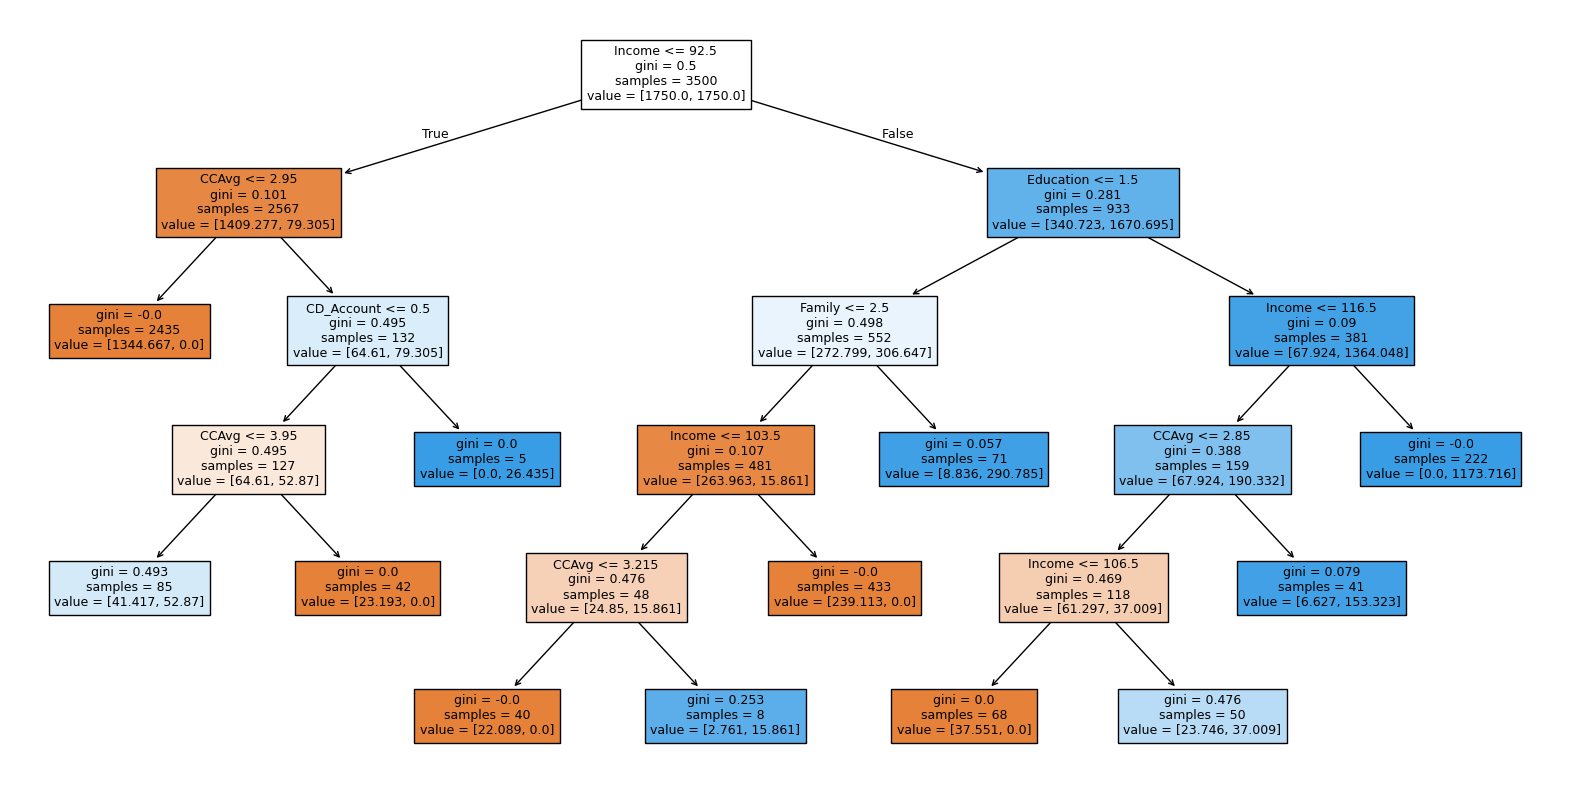

In [389]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    model4,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [390]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model4, feature_names=feature_names, show_weights=True))

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- weights: [41.42, 52.87] class: 1
|   |   |   |--- CCAvg >  3.95
|   |   |   |   |--- weights: [23.19, 0.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [0.00, 26.44] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- Income <= 103.50
|   |   |   |   |--- CCAvg <= 3.21
|   |   |   |   |   |--- weights: [22.09, 0.00] class: 0
|   |   |   |   |--- CCAvg >  3.21
|   |   |   |   |   |--- weights: [2.76, 15.86] class: 1
|   |   |   |--- Income >  103.50
|   |   |   |   |--- weights: [239.11, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [8.84, 290.79] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 116.50
|   |   |   |--- CCAvg <= 2.85
|   |   |   |   |--- Income <= 106.50
|   |   |   |   | 

In [391]:
importances = model4.feature_importances_
indices = np.argsort(importances)

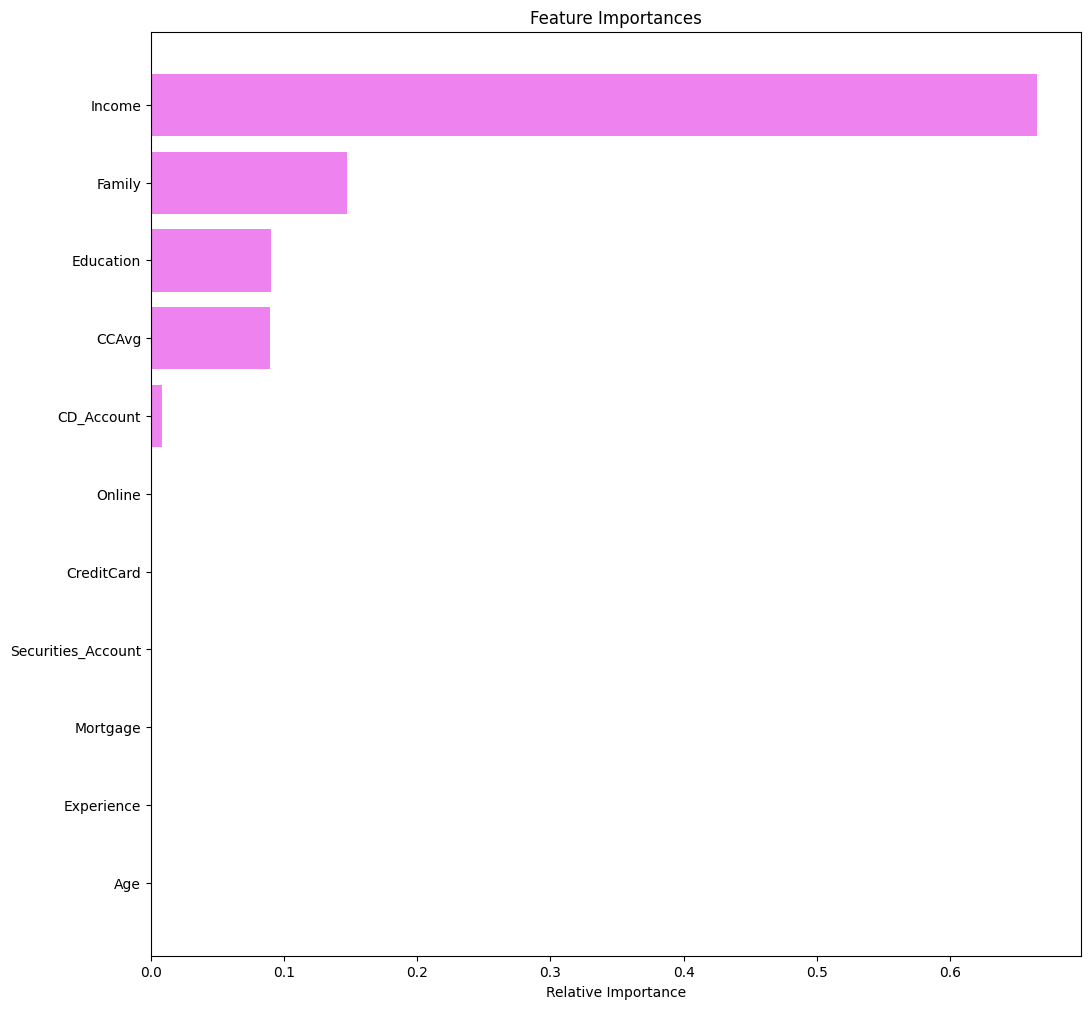

In [392]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Income is most important feature according to post pruning. Other important feature are Family, Education, CCAvg, CD_Account.

## Model Performance Comparison and Final Model Selection

In [393]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,1.0,0.956571,0.956857
Recall,1.0,1.0,0.960725,1.000000
Precision,1.0,1.0,0.695842,0.686722
F1,1.0,1.0,0.807107,0.814268


In [394]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.980000,0.974667,0.952000,0.948667
Recall,0.885906,0.859060,0.932886,0.993289
Precision,0.910345,0.882759,0.691542,0.660714
F1,0.897959,0.870748,0.794286,0.793566


* Decision tree models with post-pruning is giving high recall scores on both training and test sets.
* Therefore, we are choosing the post-pruned tree as our best model.

## Actionable Insights and Business Recommendations


- The model built can be used to predict if a customer will accept the bank loan and can correctly identify 99% of the customers who would accept the bank loan.

- Primary driver: Income

- Secondary drivers: Education, Family size, CCAvg (credit activity), CD Account presence

- High-potential targets:

  * Educated, high-income, credit-active individuals

  * Undergrad customers with large families

  * Any income group with CD account

- Low-potential segment:

  * Low-income, low CCAvg, no CD account customers → unlikely to respond to campaigns.

___